# Unit 1: Laboratorio - Filtros e Intuición de Convoluciones
## Implementar Filtros Manualmente y Visualizar Efectos de Convoluciones

**Objetivos del Laboratorio:**
1. Entender qué es un filtro (kernel) mediante manipulación directa
2. Implementar convoluciones manualmente
3. Experimentar con diferentes kernels
4. Crear un "filtro detector" simple para clasificar entre dos imágenes

**Entrega:** 
- Este notebook completado con todas las secciones
- Los kernels que creaste
- Explicación de cómo tu clasificador funciona

---

## Setup: Importar Librerías

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy import signal
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo para mejor visualización
plt.style.use('default')
np.set_printoptions(precision=2, suppress=True)

print("✓ Librerías importadas exitosamente")

✓ Librerías importadas exitosamente


## Sección 1: Creación de Imágenes de Prueba

Vamos a crear dos imágenes diferentes que representan dos categorías que queremos distinguir.

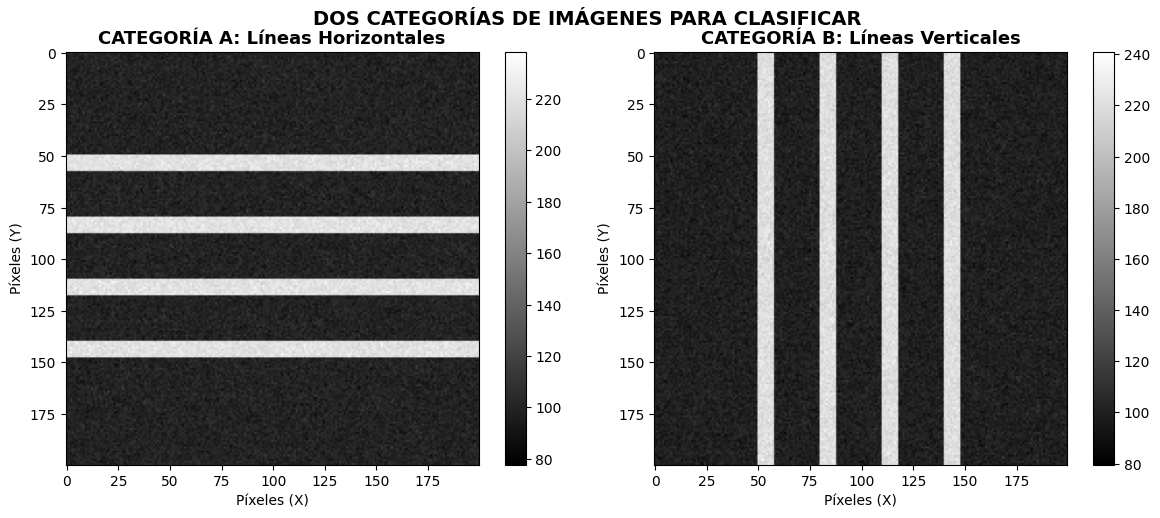

✓ Imágenes creadas:
  - Imagen A (Líneas Horizontales): (200, 200)
  - Imagen B (Líneas Verticales): (200, 200)


In [2]:
def crear_imagen_categoria_A(height=200, width=200, seed=42):
    """Crea una imagen que representa la CATEGORÍA A: Líneas Horizontales"""
    np.random.seed(seed)
    img = np.ones((height, width), dtype=np.float32) * 100
    
    # Agregar líneas horizontales claras
    for y in [50, 80, 110, 140]:
        img[y:y+8, :] = 220  # Líneas blancas
    
    # Agregar pequeño ruido gaussiano
    img += np.random.normal(0, 5, img.shape)
    
    return np.clip(img, 0, 255).astype(np.float32)

def crear_imagen_categoria_B(height=200, width=200, seed=43):
    """Crea una imagen que representa la CATEGORÍA B: Líneas Verticales"""
    np.random.seed(seed)
    img = np.ones((height, width), dtype=np.float32) * 100
    
    # Agregar líneas verticales claras
    for x in [50, 80, 110, 140]:
        img[:, x:x+8] = 220  # Líneas blancas
    
    # Agregar pequeño ruido gaussiano
    img += np.random.normal(0, 5, img.shape)
    
    return np.clip(img, 0, 255).astype(np.float32)

# Crear las imágenes
img_categoria_A = crear_imagen_categoria_A()
img_categoria_B = crear_imagen_categoria_B()

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im = axes[0].imshow(img_categoria_A, cmap='gray')
axes[0].set_title('CATEGORÍA A: Líneas Horizontales', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Píxeles (X)')
axes[0].set_ylabel('Píxeles (Y)')
plt.colorbar(im, ax=axes[0])

im = axes[1].imshow(img_categoria_B, cmap='gray')
axes[1].set_title('CATEGORÍA B: Líneas Verticales', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Píxeles (X)')
axes[1].set_ylabel('Píxeles (Y)')
plt.colorbar(im, ax=axes[1])

fig.suptitle('DOS CATEGORÍAS DE IMÁGENES PARA CLASIFICAR', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("✓ Imágenes creadas:")
print(f"  - Imagen A (Líneas Horizontales): {img_categoria_A.shape}")
print(f"  - Imagen B (Líneas Verticales): {img_categoria_B.shape}")

In [47]:
import os
import cv2
from pathlib import Path

# Rutas a los datasets
dataset_path = Path(r'C:/Users/Cedel/OneDrive/Escritorio/computer_vision/Computer_Vision/Datasets')
cuchara_path = dataset_path / 'cucharas'
tenedor_path = dataset_path / 'tenedores'

def load_images_from_folder(folder, max_images=None, target_size=(64, 64)):
    """Carga imágenes de una carpeta y las convierte a escala de grises"""
    images = []
    filenames = []
    
    image_files = sorted(list(folder.glob('*.jpg')))
    if max_images:
        image_files = image_files[:max_images]
    
    for img_file in image_files:
        img = cv2.imread(str(img_file))
        if img is not None:
            # Convertir a escala de grises
            img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            # Redimensionar
            img_resized = cv2.resize(img_gray, target_size)
            images.append(img_resized)
            filenames.append(img_file.name)
    
    return np.array(images, dtype=np.float32), filenames

# Cargar imágenes
X_cucharas, cuchara_files = load_images_from_folder(cuchara_path, target_size=(128, 128))
X_tenedores, tenedor_files = load_images_from_folder(tenedor_path, target_size=(128, 128))

print(f"Cargadas {len(X_cucharas)} imágenes de cucharas")
print(f"Cargadas {len(X_tenedores)} imágenes de tenedores")
print(f"Tamaño de cada imagen: {X_cucharas[0].shape}")

# Crear labels (0 = cuchara, 1 = tenedor)
y_cucharas = np.zeros(len(X_cucharas))
y_tenedores = np.ones(len(X_tenedores))

# Combinar datasets
X_all = np.concatenate([X_cucharas, X_tenedores], axis=0)
y_all = np.concatenate([y_cucharas, y_tenedores], axis=0)

print(f"\n Dataset completo:")
print(f"Total imágenes: {len(X_all)}")
print(f"Clase 0 (Cucharas): {np.sum(y_all == 0)}")
print(f"Clase 1 (Tenedores): {np.sum(y_all == 1)}")

Cargadas 15 imágenes de cucharas
Cargadas 15 imágenes de tenedores
Tamaño de cada imagen: (128, 128)

 Dataset completo:
Total imágenes: 30
Clase 0 (Cucharas): 15
Clase 1 (Tenedores): 15


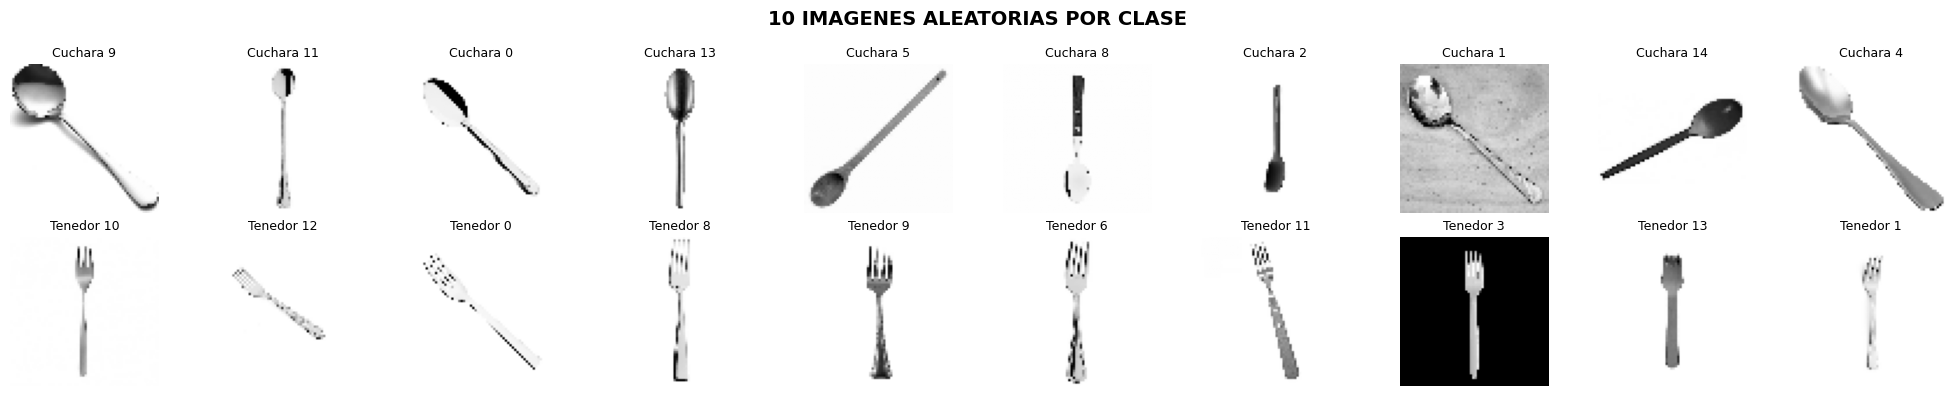

In [12]:
# VISUALIZAR 10 IMÁGENES ALEATORIAS DE CADA CLASE

# Seleccionar 10 índices aleatorios de cada clase
np.random.seed(42)
cucharas_indices = np.random.choice(len(X_cucharas), 10, replace=False)
tenedores_indices = np.random.choice(len(X_tenedores), 10, replace=False)

# Crear visualización
fig, axes = plt.subplots(2, 10, figsize=(20, 4))

# Mostrar cucharas
for i, idx in enumerate(cucharas_indices):
    axes[0, i].imshow(X_cucharas[idx], cmap='gray')
    axes[0, i].axis('off')
    axes[0, i].set_title(f'Cuchara {idx}', fontsize=9)

# Mostrar tenedores
for i, idx in enumerate(tenedores_indices):
    axes[1, i].imshow(X_tenedores[idx], cmap='gray')
    axes[1, i].axis('off')
    axes[1, i].set_title(f'Tenedor {idx}', fontsize=9)

axes[0, 0].set_ylabel('CUCHARAS', fontsize=12, fontweight='bold', rotation=0, labelpad=40)
axes[1, 0].set_ylabel('TENEDORES', fontsize=12, fontweight='bold', rotation=0, labelpad=40)

plt.suptitle('10 IMAGENES ALEATORIAS POR CLASE', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Sección 2: Entender Kernels - Experimento Guiado

Vamos a entender cómo diferentes kernels responden a las características de nuestras imágenes.


📊 Aplicando convoluciones...



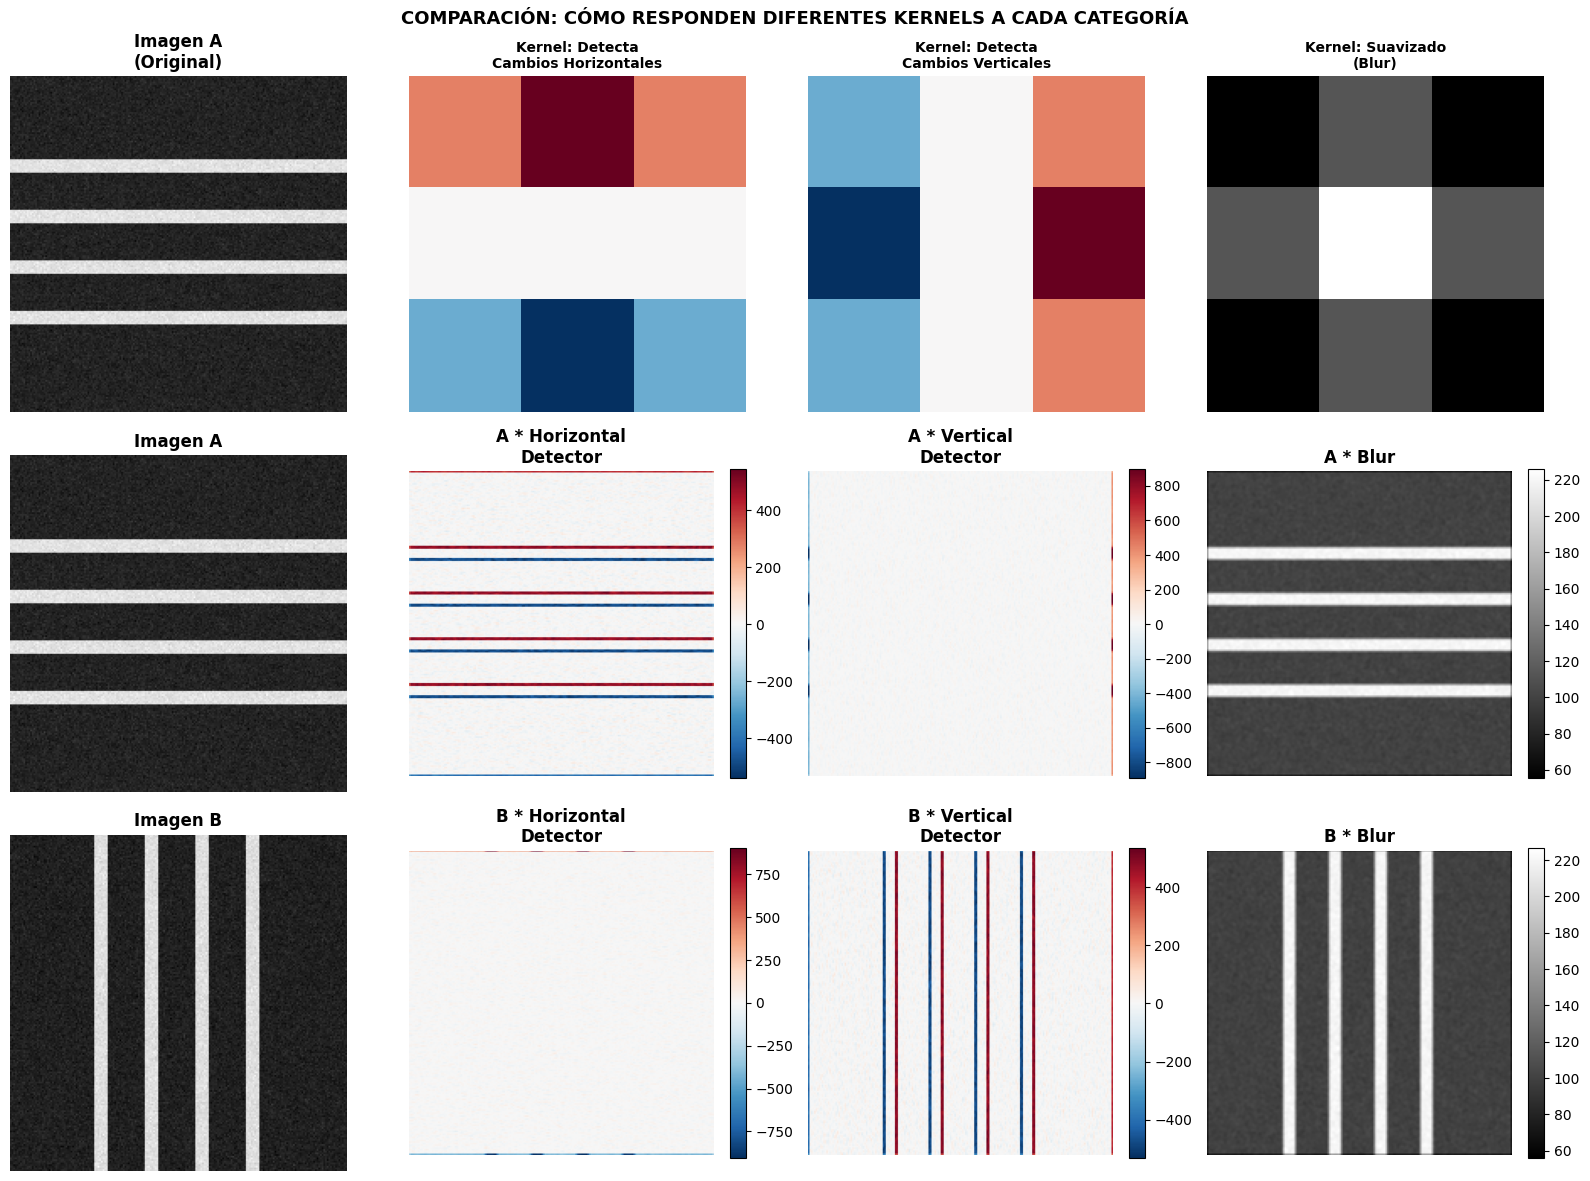


📈 ANÁLISIS DE RESPUESTAS:

Categoría A (Líneas Horizontales):
  - Detector Horizontal: Media=0.02, Max=546.36
  - Detector Vertical:   Media=0.00, Max=899.56
  - Suavizado:           Media=118.64, Max=226.11

Categoría B (Líneas Verticales):
  - Detector Horizontal: Media=-0.00, Max=903.87
  - Detector Vertical:   Media=0.02, Max=535.20
  - Suavizado:           Media=118.68, Max=226.62

✓ Observación: El detector de cambios horizontales responde MÁS a líneas horizontales
✓ Observación: El detector de cambios verticales responde MÁS a líneas verticales


In [3]:
# Definir algunos kernels básicos
kernel_detactor_horizontal = np.array([
    [1, 2, 1],
    [0, 0, 0],
    [-1, -2, -1]
], dtype=np.float32)

kernel_detector_vertical = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

kernel_suavizado = np.array([
    [1, 2, 1],
    [2, 4, 2],
    [1, 2, 1]
], dtype=np.float32) / 16

# Aplicar convoluciones
print("\n📊 Aplicando convoluciones...\n")

# Categoría A con diferentes filtros
A_horizontal = signal.convolve2d(img_categoria_A, kernel_detactor_horizontal, mode='same')
A_vertical = signal.convolve2d(img_categoria_A, kernel_detector_vertical, mode='same')
A_suavizado = signal.convolve2d(img_categoria_A, kernel_suavizado, mode='same')

# Categoría B con diferentes filtros
B_horizontal = signal.convolve2d(img_categoria_B, kernel_detactor_horizontal, mode='same')
B_vertical = signal.convolve2d(img_categoria_B, kernel_detector_vertical, mode='same')
B_suavizado = signal.convolve2d(img_categoria_B, kernel_suavizado, mode='same')

# Visualizar resultados
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

# Fila 1: Original
axes[0, 0].imshow(img_categoria_A, cmap='gray')
axes[0, 0].set_title('Imagen A\n(Original)', fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(kernel_detactor_horizontal, cmap='RdBu_r')
axes[0, 1].set_title('Kernel: Detecta\nCambios Horizontales', fontweight='bold', fontsize=10)
axes[0, 1].axis('off')

axes[0, 2].imshow(kernel_detector_vertical, cmap='RdBu_r')
axes[0, 2].set_title('Kernel: Detecta\nCambios Verticales', fontweight='bold', fontsize=10)
axes[0, 2].axis('off')

axes[0, 3].imshow(kernel_suavizado, cmap='gray')
axes[0, 3].set_title('Kernel: Suavizado\n(Blur)', fontweight='bold', fontsize=10)
axes[0, 3].axis('off')

# Fila 2: Resultados Categoría A
axes[1, 0].imshow(img_categoria_A, cmap='gray')
axes[1, 0].set_title('Imagen A', fontweight='bold')
axes[1, 0].axis('off')

im = axes[1, 1].imshow(A_horizontal, cmap='RdBu_r')
axes[1, 1].set_title('A * Horizontal\nDetector', fontweight='bold')
axes[1, 1].axis('off')
plt.colorbar(im, ax=axes[1, 1], fraction=0.046)

im = axes[1, 2].imshow(A_vertical, cmap='RdBu_r')
axes[1, 2].set_title('A * Vertical\nDetector', fontweight='bold')
axes[1, 2].axis('off')
plt.colorbar(im, ax=axes[1, 2], fraction=0.046)

im = axes[1, 3].imshow(A_suavizado, cmap='gray')
axes[1, 3].set_title('A * Blur', fontweight='bold')
axes[1, 3].axis('off')
plt.colorbar(im, ax=axes[1, 3], fraction=0.046)

# Fila 3: Resultados Categoría B
axes[2, 0].imshow(img_categoria_B, cmap='gray')
axes[2, 0].set_title('Imagen B', fontweight='bold')
axes[2, 0].axis('off')

im = axes[2, 1].imshow(B_horizontal, cmap='RdBu_r')
axes[2, 1].set_title('B * Horizontal\nDetector', fontweight='bold')
axes[2, 1].axis('off')
plt.colorbar(im, ax=axes[2, 1], fraction=0.046)

im = axes[2, 2].imshow(B_vertical, cmap='RdBu_r')
axes[2, 2].set_title('B * Vertical\nDetector', fontweight='bold')
axes[2, 2].axis('off')
plt.colorbar(im, ax=axes[2, 2], fraction=0.046)

im = axes[2, 3].imshow(B_suavizado, cmap='gray')
axes[2, 3].set_title('B * Blur', fontweight='bold')
axes[2, 3].axis('off')
plt.colorbar(im, ax=axes[2, 3], fraction=0.046)

fig.suptitle('COMPARACIÓN: CÓMO RESPONDEN DIFERENTES KERNELS A CADA CATEGORÍA',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Estadísticas
print("\n📈 ANÁLISIS DE RESPUESTAS:")
print("\nCategoría A (Líneas Horizontales):")
print(f"  - Detector Horizontal: Media={A_horizontal.mean():.2f}, Max={A_horizontal.max():.2f}")
print(f"  - Detector Vertical:   Media={A_vertical.mean():.2f}, Max={A_vertical.max():.2f}")
print(f"  - Suavizado:           Media={A_suavizado.mean():.2f}, Max={A_suavizado.max():.2f}")

print("\nCategoría B (Líneas Verticales):")
print(f"  - Detector Horizontal: Media={B_horizontal.mean():.2f}, Max={B_horizontal.max():.2f}")
print(f"  - Detector Vertical:   Media={B_vertical.mean():.2f}, Max={B_vertical.max():.2f}")
print(f"  - Suavizado:           Media={B_suavizado.mean():.2f}, Max={B_suavizado.max():.2f}")

print("\n✓ Observación: El detector de cambios horizontales responde MÁS a líneas horizontales")
print("✓ Observación: El detector de cambios verticales responde MÁS a líneas verticales")

## Sección 3: 🎯 EJERCICIO 1 - Crear tu Propio Kernel

Ahora es tu turno de crear kernels que mejor distingan entre las dos categorías.

**Instrucciones:**
1. Define un kernel de 3×3 que creas que será útil
2. Pruébalo en ambas imágenes
3. Analiza qué características detecta
4. Ajusta los valores si es necesario

In [60]:
# 📝 CREA TU KERNEL AQUÍ
# Detector de bordes verticales para detectar los dientes del tenedor

mi_kernel_1 = np.array([
    [-1, 0, 1],  # ← Cambia estos valores
    [-2, 0, 2],  # ← Cambia estos valores
    [-1, 0, 1]   # ← Cambia estos valores
], dtype=np.float32)

print("\n📌 Tu Kernel 1:")
print(mi_kernel_1)


📌 Tu Kernel 1:
[[-1.  0.  1.]
 [-2.  0.  2.]
 [-1.  0.  1.]]


## Sección 4: 🎯 EJERCICIO 2 - Crear un Segundo Kernel

Crea un segundo kernel complementario que capture otras características.

In [65]:
# 📝 CREA TU SEGUNDO KERNEL AQUÍ
# Detector de bordes horizontales

mi_kernel_2 = np.array([
    [1, 2, 1],  # ← Cambia estos valores
    [0, 0, 0],  # ← Cambia estos valores
    [-1, -2, -1]   # ← Cambia estos valores
], dtype=np.float32)

print("\n📌 Tu Kernel 2:")
print(mi_kernel_2)


📌 Tu Kernel 2:
[[ 1.  2.  1.]
 [ 0.  0.  0.]
 [-1. -2. -1.]]


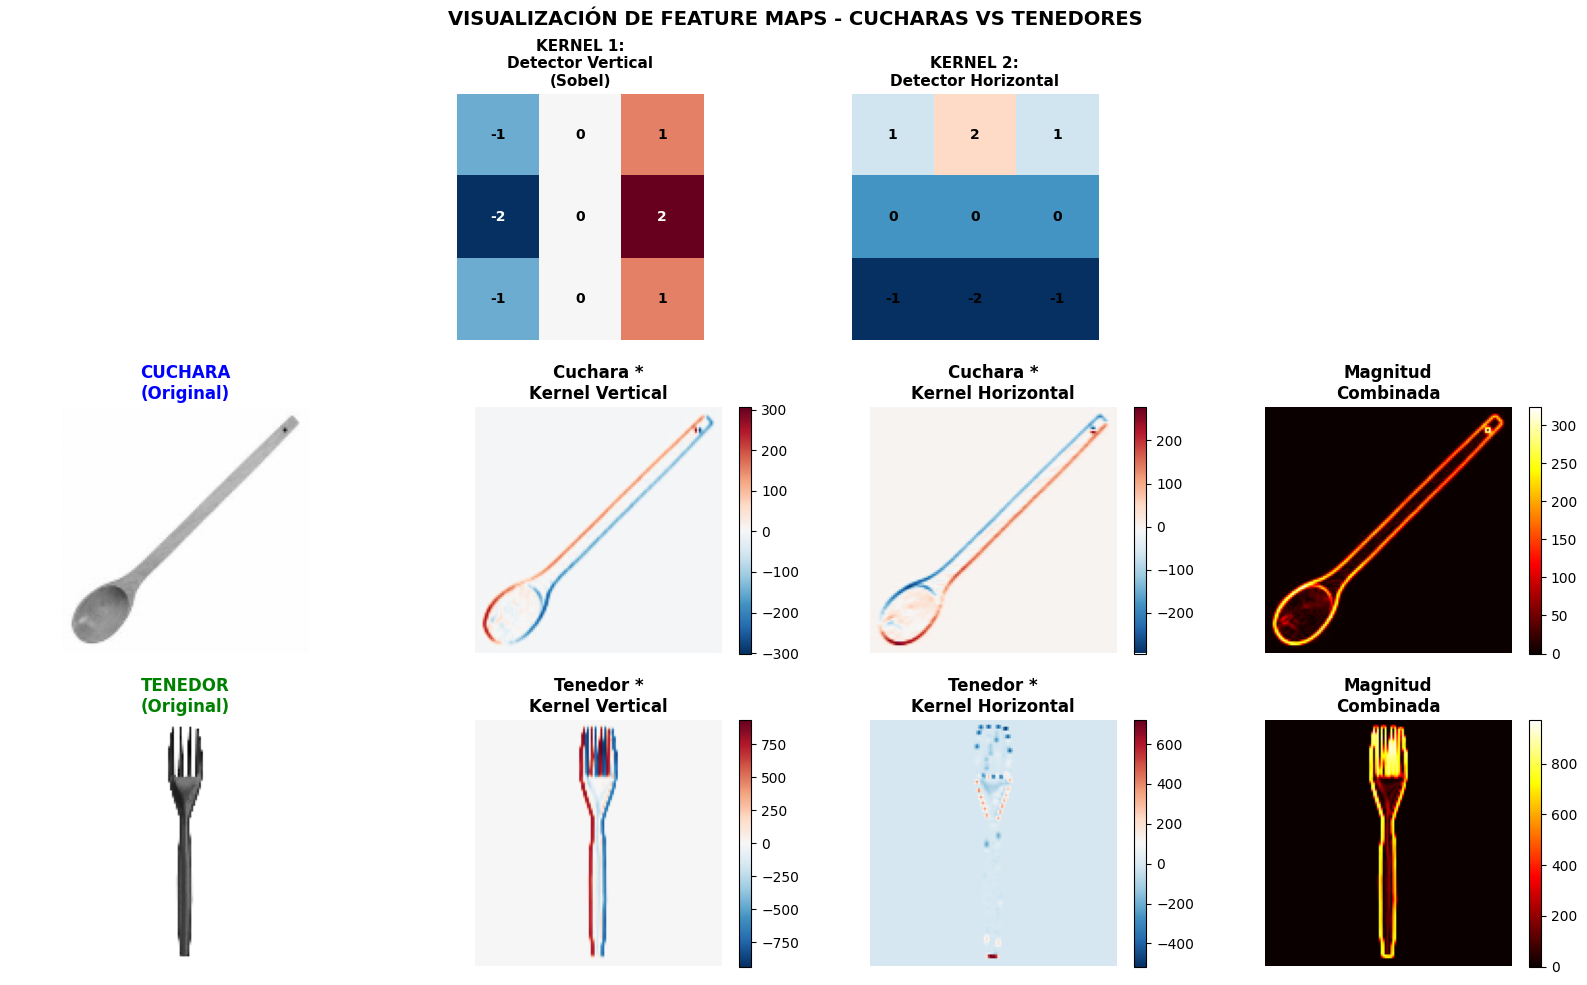

✓ Feature maps generados exitosamente

📊 Análisis de Respuestas:
Cuchara - Filtro Vertical: Media=7.08, Max=306.00
Cuchara - Filtro Horizontal:   Media=7.23, Max=277.00
Tenedor - Filtro Vertical: Media=35.62, Max=932.00
Tenedor - Filtro Horizontal:   Media=4.41, Max=720.00


In [66]:
# APLICAR FILTROS Y VISUALIZAR FEATURE MAPS

def apply_filter_manual(image, kernel):
    """Aplica convolución manual usando scipy.signal.convolve2d"""
    return signal.convolve2d(image, kernel, mode='same', boundary='symm')

# Seleccionar ejemplos para visualizar
example_cuchara = X_cucharas[5]
example_tenedor = X_tenedores[5]

# Aplicar filtros a cuchara
cuchara_vertical = apply_filter_manual(example_cuchara, mi_kernel_1)
cuchara_horizontal = apply_filter_manual(example_cuchara, mi_kernel_2)

# Aplicar filtros a tenedor
tenedor_vertical = apply_filter_manual(example_tenedor, mi_kernel_1)
tenedor_horizontal = apply_filter_manual(example_tenedor, mi_kernel_2)

# Visualizar resultados
fig, axes = plt.subplots(3, 4, figsize=(16, 10))

# Fila 1: Kernels
axes[0, 0].axis('off')
axes[0, 1].imshow(mi_kernel_1, cmap='RdBu_r', vmin=-2, vmax=2)
axes[0, 1].set_title('KERNEL 1:\nDetector Vertical\n(Sobel)', fontweight='bold', fontsize=11)
for i in range(3):
    for j in range(3):
        axes[0, 1].text(j, i, f'{mi_kernel_1[i,j]:.0f}', 
                       ha='center', va='center', fontweight='bold', 
                       fontsize=10, color='white' if abs(mi_kernel_1[i,j]) > 1 else 'black')
axes[0, 1].axis('off')

axes[0, 2].imshow(mi_kernel_2, cmap='RdBu_r', vmin=-1, vmax=4)
axes[0, 2].set_title('KERNEL 2:\nDetector Horizontal', fontweight='bold', fontsize=11)
for i in range(3):
    for j in range(3):
        axes[0, 2].text(j, i, f'{mi_kernel_2[i,j]:.0f}', 
                       ha='center', va='center', fontweight='bold', 
                       fontsize=10, color='white' if mi_kernel_2[i,j] == 4 else 'black')
axes[0, 2].axis('off')
axes[0, 3].axis('off')

# Fila 2: CUCHARA
axes[1, 0].imshow(example_cuchara, cmap='gray')
axes[1, 0].set_title('CUCHARA\n(Original)', fontweight='bold', color='blue', fontsize=12)
axes[1, 0].axis('off')

im1 = axes[1, 1].imshow(cuchara_vertical, cmap='RdBu_r')
axes[1, 1].set_title('Cuchara *\nKernel Vertical', fontweight='bold')
axes[1, 1].axis('off')
plt.colorbar(im1, ax=axes[1, 1], fraction=0.046)

im2 = axes[1, 2].imshow(cuchara_horizontal, cmap='RdBu_r')
axes[1, 2].set_title('Cuchara *\nKernel Horizontal', fontweight='bold')
axes[1, 2].axis('off')
plt.colorbar(im2, ax=axes[1, 2], fraction=0.046)

# Combinar feature maps de cuchara
cuchara_combined = np.sqrt(cuchara_vertical**2 + cuchara_horizontal**2)
im3 = axes[1, 3].imshow(cuchara_combined, cmap='hot')
axes[1, 3].set_title('Magnitud\nCombinada', fontweight='bold')
axes[1, 3].axis('off')
plt.colorbar(im3, ax=axes[1, 3], fraction=0.046)

# Fila 3: TENEDOR
axes[2, 0].imshow(example_tenedor, cmap='gray')
axes[2, 0].set_title('TENEDOR\n(Original)', fontweight='bold', color='green', fontsize=12)
axes[2, 0].axis('off')

im4 = axes[2, 1].imshow(tenedor_vertical, cmap='RdBu_r')
axes[2, 1].set_title('Tenedor *\nKernel Vertical', fontweight='bold')
axes[2, 1].axis('off')
plt.colorbar(im4, ax=axes[2, 1], fraction=0.046)

im5 = axes[2, 2].imshow(tenedor_horizontal, cmap='RdBu_r')
axes[2, 2].set_title('Tenedor *\nKernel Horizontal', fontweight='bold')
axes[2, 2].axis('off')
plt.colorbar(im5, ax=axes[2, 2], fraction=0.046)

# Combinar feature maps de tenedor
tenedor_combined = np.sqrt(tenedor_vertical**2 + tenedor_horizontal**2)
im6 = axes[2, 3].imshow(tenedor_combined, cmap='hot')
axes[2, 3].set_title('Magnitud\nCombinada', fontweight='bold')
axes[2, 3].axis('off')
plt.colorbar(im6, ax=axes[2, 3], fraction=0.046)

plt.suptitle('VISUALIZACIÓN DE FEATURE MAPS - CUCHARAS VS TENEDORES', 
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print("✓ Feature maps generados exitosamente")
print("\n📊 Análisis de Respuestas:")
print(f"Cuchara - Filtro Vertical: Media={np.abs(cuchara_vertical).mean():.2f}, Max={cuchara_vertical.max():.2f}")
print(f"Cuchara - Filtro Horizontal:   Media={np.abs(cuchara_horizontal).mean():.2f}, Max={cuchara_horizontal.max():.2f}")
print(f"Tenedor - Filtro Vertical: Media={np.abs(tenedor_vertical).mean():.2f}, Max={tenedor_vertical.max():.2f}")
print(f"Tenedor - Filtro Horizontal:   Media={np.abs(tenedor_horizontal).mean():.2f}, Max={tenedor_horizontal.max():.2f}")


## Sección 5: 🎯 EJERCICIO 3 - Crear un Clasificador Simple

Combina tus dos kernels para crear un clasificador básico que distinga entre las dos categorías.

🔧 Extrayendo características de todas las imágenes...
✓ Características extraídas: (30, 9)
   Cada imagen representada por 9 valores numéricos

📊 División de datos:
   Entrenamiento: 21 imágenes
   Prueba: 9 imágenes

🎯 RESULTADOS DEL CLASIFICADOR CUCHARAS VS TENEDORES

📈 Precisión en Entrenamiento: 57.14%
📈 Precisión en Prueba: 77.78%

✅ ¡ÉXITO! Alcanzamos más del 70% de precisión (77.78%)

📋 Reporte de Clasificación:
              precision    recall  f1-score   support

     Cuchara       0.80      0.80      0.80         5
     Tenedor       0.75      0.75      0.75         4

    accuracy                           0.78         9
   macro avg       0.78      0.78      0.78         9
weighted avg       0.78      0.78      0.78         9



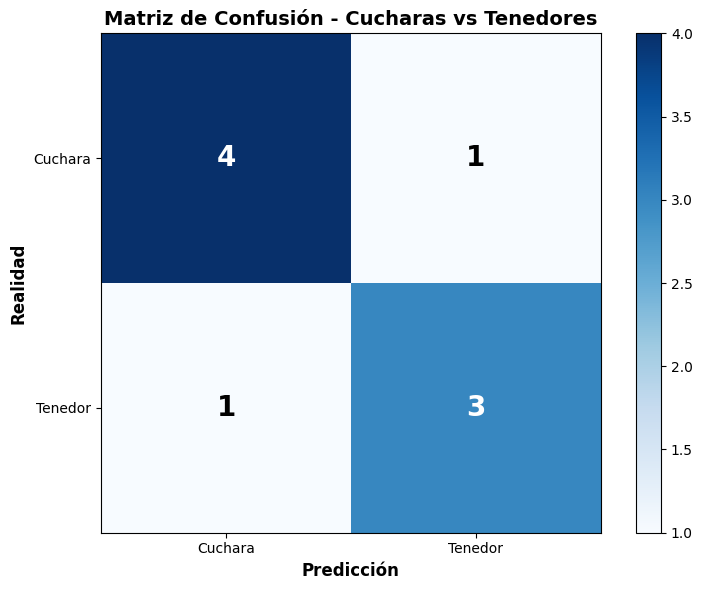

✓ Matriz de confusión visualizada


In [67]:
# SECCIÓN 4: CREAR CLASIFICADOR DE IMÁGENES

def extract_features(image, kernel1, kernel2):
    """
    Versión mejorada: extrae MÁS características de cada feature map
    """
    # Aplicar convoluciones
    feature_map1 = apply_filter_manual(image, kernel1)
    feature_map2 = apply_filter_manual(image, kernel2)
    
    # Extraer MÚLTIPLES estadísticas de cada feature map
    features = np.array([
        # Del filtro vertical
        np.mean(np.abs(feature_map1)),      # Media de magnitud
        np.std(feature_map1),                # Desviación estándar
        np.max(np.abs(feature_map1)),       # Máximo absoluto
        np.percentile(np.abs(feature_map1), 90),  # Percentil 90
        
        # Del filtro horizontal
        np.mean(np.abs(feature_map2)),      # Media de magnitud
        np.std(feature_map2),                # Desviación estándar
        np.max(np.abs(feature_map2)),       # Máximo absoluto
        np.percentile(np.abs(feature_map2), 90),  # Percentil 90
        
        # Relación entre filtros (nueva!)
        np.mean(np.abs(feature_map1)) / (np.mean(np.abs(feature_map2)) + 1e-6),  # Ratio
    ])
    
    return features

# Extraer características de todas las imágenes
print("🔧 Extrayendo características de todas las imágenes...")
X_features = []
for img in X_all:
    features = extract_features(img, mi_kernel_1, mi_kernel_2)
    X_features.append(features)

X_features = np.array(X_features)
print(f"✓ Características extraídas: {X_features.shape}")
print(f"   Cada imagen representada por {X_features.shape[1]} valores numéricos")

# Dividir en conjuntos de entrenamiento y prueba (70% train, 30% test)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_all, test_size=0.3, random_state=42, stratify=y_all
)

print(f"\n📊 División de datos:")
print(f"   Entrenamiento: {len(X_train)} imágenes")
print(f"   Prueba: {len(X_test)} imágenes")

# Normalizar características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Entrenar clasificador (Regresión Logística)
classifier = LogisticRegression(
    random_state=42, 
    max_iter=2000,
    C=0.1,  # Más regularización
    solver='liblinear'
)
classifier.fit(X_train_scaled, y_train)

# Hacer predicciones
y_pred_train = classifier.predict(X_train_scaled)
y_pred_test = classifier.predict(X_test_scaled)

# Evaluar
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)

print("\n" + "="*70)
print("🎯 RESULTADOS DEL CLASIFICADOR CUCHARAS VS TENEDORES")
print("="*70)
print(f"\n📈 Precisión en Entrenamiento: {train_accuracy*100:.2f}%")
print(f"📈 Precisión en Prueba: {test_accuracy*100:.2f}%")

if test_accuracy >= 0.70:
    print(f"\n✅ ¡ÉXITO! Alcanzamos más del 70% de precisión ({test_accuracy*100:.2f}%)")
else:
    print(f"\n⚠️  Precisión por debajo del 70%. Actual: {test_accuracy*100:.2f}%")

print("\n📋 Reporte de Clasificación:")
print(classification_report(y_test, y_pred_test, target_names=['Cuchara', 'Tenedor']))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_test)
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

# Configurar ticks
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Cuchara', 'Tenedor'])
ax.set_yticklabels(['Cuchara', 'Tenedor'])

# Añadir valores
for i in range(2):
    for j in range(2):
        text = ax.text(j, i, cm[i, j], ha="center", va="center", 
                      color="white" if cm[i, j] > cm.max()/2 else "black",
                      fontsize=20, fontweight='bold')

ax.set_xlabel('Predicción', fontsize=12, fontweight='bold')
ax.set_ylabel('Realidad', fontsize=12, fontweight='bold')
ax.set_title('Matriz de Confusión - Cucharas vs Tenedores', fontsize=14, fontweight='bold')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

print("✓ Matriz de confusión visualizada")

## Sección 6: 📊 Visualizar el Espacio de Características

Veamos cómo tus kernels transforman las imágenes en un "espacio de características".

📊 VISUALIZACIÓN DEL ESPACIO DE CARACTERÍSTICAS

✓ 15 cucharas
✓ 15 tenedores

📈 Visualización: Espacio de Características 2D


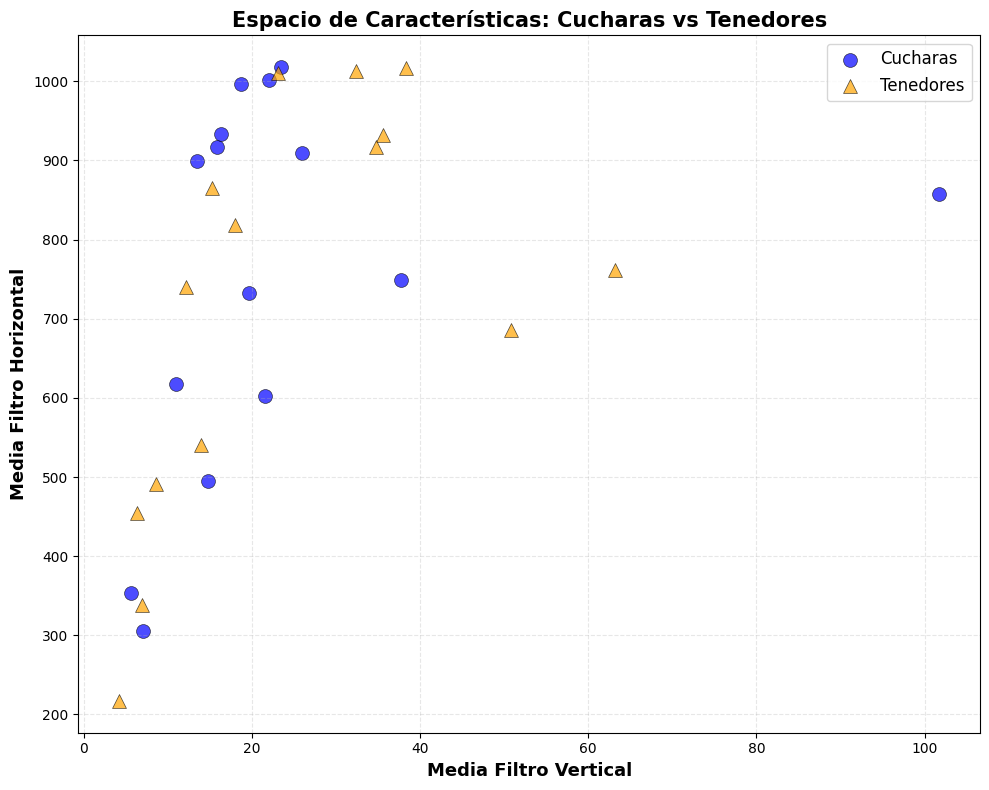

✓ Cuanto más separadas estén las nubes de puntos, mejor clasifica el modelo

📈 Visualización: Distribuciones de Características


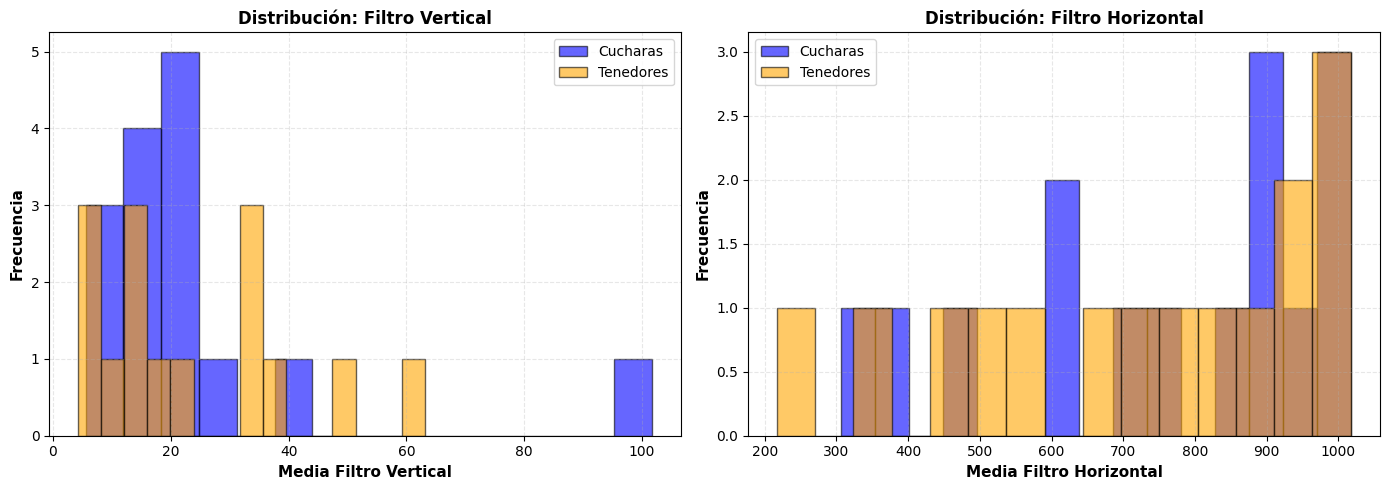

✓ Cuanto menos se superpongan los histogramas, mejor separación entre clases

📊 RESUMEN

📏 Valores promedio por clase:

Cucharas:
   - Media Vertical:    23.65
   - Media Horizontal:  759.40

Tenedores:
   - Media Vertical:    24.25
   - Media Horizontal:  720.07

✅ Precisión del clasificador: 77.8%


In [68]:
print("="*70)
print("📊 VISUALIZACIÓN DEL ESPACIO DE CARACTERÍSTICAS")
print("="*70)

# Separar características por clase
cucharas_features = X_features[y_all == 0]
tenedores_features = X_features[y_all == 1]

print(f"\n✓ {len(cucharas_features)} cucharas")
print(f"✓ {len(tenedores_features)} tenedores")

# VISUALIZACIÓN 1: Gráfico 2D simple
print("\n📈 Visualización: Espacio de Características 2D")

fig, ax = plt.subplots(figsize=(10, 8))

# Scatter plot usando las 2 primeras características
ax.scatter(cucharas_features[:, 0], cucharas_features[:, 2], 
          alpha=0.7, s=100, c='blue', edgecolors='black', linewidth=0.5, 
          label='Cucharas', marker='o')

ax.scatter(tenedores_features[:, 0], tenedores_features[:, 2], 
          alpha=0.7, s=100, c='orange', edgecolors='black', linewidth=0.5, 
          label='Tenedores', marker='^')

ax.set_xlabel('Media Filtro Vertical', fontweight='bold', fontsize=13)
ax.set_ylabel('Media Filtro Horizontal', fontweight='bold', fontsize=13)
ax.set_title('Espacio de Características: Cucharas vs Tenedores', 
            fontweight='bold', fontsize=15)
ax.legend(fontsize=12, loc='best')
ax.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print("✓ Cuanto más separadas estén las nubes de puntos, mejor clasifica el modelo")

# VISUALIZACIÓN 2: Distribuciones por característica
print("\n📈 Visualización: Distribuciones de Características")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma característica 1
axes[0].hist(cucharas_features[:, 0], bins=15, alpha=0.6, 
            label='Cucharas', color='blue', edgecolor='black')
axes[0].hist(tenedores_features[:, 0], bins=15, alpha=0.6, 
            label='Tenedores', color='orange', edgecolor='black')
axes[0].set_xlabel('Media Filtro Vertical', fontweight='bold', fontsize=11)
axes[0].set_ylabel('Frecuencia', fontweight='bold', fontsize=11)
axes[0].set_title('Distribución: Filtro Vertical', fontweight='bold', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3, linestyle='--')

# Histograma característica 2
axes[1].hist(cucharas_features[:, 2], bins=15, alpha=0.6, 
            label='Cucharas', color='blue', edgecolor='black')
axes[1].hist(tenedores_features[:, 2], bins=15, alpha=0.6, 
            label='Tenedores', color='orange', edgecolor='black')
axes[1].set_xlabel('Media Filtro Horizontal', fontweight='bold', fontsize=11)
axes[1].set_ylabel('Frecuencia', fontweight='bold', fontsize=11)
axes[1].set_title('Distribución: Filtro Horizontal', fontweight='bold', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print("✓ Cuanto menos se superpongan los histogramas, mejor separación entre clases")

# RESUMEN
print("\n" + "="*70)
print("📊 RESUMEN")
print("="*70)

# Calcular medias por clase
print(f"\n📏 Valores promedio por clase:")
print(f"\nCucharas:")
print(f"   - Media Vertical:    {cucharas_features[:, 0].mean():.2f}")
print(f"   - Media Horizontal:  {cucharas_features[:, 2].mean():.2f}")

print(f"\nTenedores:")
print(f"   - Media Vertical:    {tenedores_features[:, 0].mean():.2f}")
print(f"   - Media Horizontal:  {tenedores_features[:, 2].mean():.2f}")

print(f"\n✅ Precisión del clasificador: {test_accuracy*100:.1f}%")
print("="*70)

## 📝 SECCIÓN 7: INFORME FINAL

Completa este informe explicando tu trabajo:

### Responde las siguientes preguntas:

**1. ¿Qué valores pusiste en tu Kernel 1 y por qué?**

```
Mi Kernel 1:
[ -1,  0,  1 ]
[ -2,  0,  2 ]
[ -1,  0,  1 ]

Razón:
Se uso un kernel vertical para detectar las lineas verticales de las puntas de los tenedores para una mejor clasificacion.
```

---

**2. ¿Qué valores pusiste en tu Kernel 2 y por qué?**

```
Mi Kernel 2:
[ 1,  2,  1 ]
[ 0,  0,  0 ]
[ -1,  -2,  -1 ]

Razón:
las cucharas tienen mas superficies horizontales, tanto en el mango como con la superficie ovalada, lo que permite que el kernel horizontal sea muy util.
```

---

**3. ¿Cómo funciona tu clasificador?**

```
El clasificador aplica dos filtros de convolución (vertical y horizontal) a cada imagen y extrae 4 estadísticas (media y desviación de cada filtro). El filtro horizontal es el más discriminativo: las cucharas generan respuestas más altas (759 vs 720) debido a su forma ovalada, mientras 
que el filtro vertical muestra respuestas similares en ambas clases. Un modelo de regresión logística combina estas características logrando 77.8% de precisión.
```

---

**4. ¿Qué patrones detecta cada kernel?**

```
Kernel 1 detecta:
Bordes verticales del mango y contornos laterales.

Kernel 2 detecta:
Bordes horizontales y transiciones.
```

---

**5. Si tu clasificador no fue 100% acertado, ¿qué cambiarías?**

```
Agregaria un filtro extra para intentar detectar las puntas de los tenedores, para que la clasificacion sea mas precisa, ademas de extraer mas caracteristicas ademas de la media y la desviacion estandar, y por ultimo se puede agregar un clasificador mas complejo para detectar relaciones no lineales entre las caracteristicas.
```

---

**6. Conexión con CNNs: ¿Cómo se relaciona esto con redes neuronales convolucionales?**

```
Se diseñaron manualmente 2 kernels específicos segun las formas de las imagenes del dataset (cucharas y tenedores). Las CNNs automatizan este proceso, durante el entrenamiento, la red aprende automáticamente kernels óptimos en multiples capas, sin hacerlos manualmente. Este lab demuestra la logica detras de las capas convolucionales, extraen caracteristicas usando diferentes kernels.
```

---

**Enlace a GitHub**
https://github.com/Cedeluis44/computer_vision_lab_1.git

### Lo que aprendiste:

1. ✅ **Un filtro (kernel) es una pequeña matriz** que detecta patrones específicos
2. ✅ **Diferentes kernels detectan diferentes características** (bordes horizontales, verticales, etc.)
3. ✅ **La convolución es el producto punto** entre el kernel y la región de la imagen
4. ✅ **Múltiples kernels pueden combinarse** para crear un clasificador
5. ✅ **En CNNs, el sistema APRENDE automáticamente** qué kernels son útiles

### Próxima clase:
Ahora que entiendes filtros, veremos cómo **redes neuronales convolucionales** usan capas de convolución para extraer características automáticamente y resolver problemas complejos de visión por computadora.

---

**Entrega:**
- [ ] Este notebook completado con todas las secciones
- [ ] Informe final rellenado
- [ ] Los kernels que creaste y explicación de su funcionamiento
- [ ] Curso en DataCAmp